In [95]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

work_path = Path(next((p for p in Path("__file__").resolve().parents if p.name == "research"), None))
tools_path = str(work_path / Path("../torch-tools"))
sys.path.append(tools_path)

from run_manager import RunViewer


In [96]:
nb_path = Path().resolve()
rv = RunViewer(exp_path=nb_path)
df_base = rv.fetch_results(met_listed=False)

df_base = pl.read_csv("/home/tat/research/ee/old_exp/ee_cifar100/exp_cifar100/results.csv")


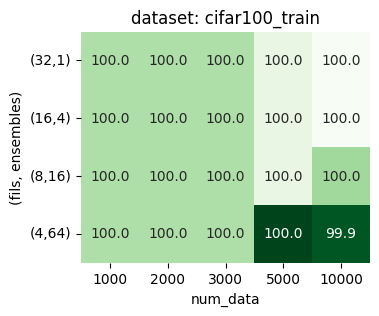

In [97]:
df = df_base

# df = df.with_columns((pl.col("epochs") * pl.col("train_num")).round_sig_figs(3).alias("base_iter"))
# df = df.with_columns((pl.col("base_iter") // 10000).cast(pl.String).alias("base_epochs"))
df = df.with_columns((pl.col("fils") ** 2 * pl.col("ensembles").cast(pl.Int32)).alias("base_ch"))

df = df.filter(pl.col("base_ch")==1024).sort("ensembles")
df = df.filter(pl.col("num_data").is_in([1000, 2000, 3000, 5000, 10000]))
df = df.filter(pl.col("fils").is_in([32, 16, 8, 4]))
# df = df.filter(pl.col("max_lr")==0.1)

piv_values = ["train_acc"]
piv_index = ["fils", "ensembles"]
piv_on = "num_data"
# piv_on = "train_num"

# agg = "len"
agg = "mean"

ext_column = "dataset" # このカラムの要素ごとにheatmapを表示
# ext_column = "base_epochs" # このカラムの要素ごとにheatmapを表示
# piv_on = "data_per_class"
# ext_column = "num_classes" # このカラムの要素ごとにheatmapを表示

ext_l = df[ext_column].unique()

for ext in ext_l:
    # pivot table 作成
    df_ext = df.filter(pl.col(ext_column) == ext)
    df_piv = df_ext.pivot(values=piv_values, index=piv_index, on=piv_on, sort_columns=True, aggregate_function=agg)

    # カラムが文字列順になっているため、数字部分をソート
    _num_columns = sorted(int(x) for x in df_piv.columns if x.isdigit())
    new_columns = [str(_num_columns.pop(0)) if x.isdigit() else x for x in df_piv.columns]
    df_piv = df_piv.select(new_columns)

    # (fil, ensemble) の形式に
    df_piv = df_piv.with_columns(("(" + pl.col("fils").cast(pl.String) + "," + pl.col("ensembles").cast(pl.String)).alias("(fils, ensembles)") + ")")
    df_piv = df_piv.select(["(fils, ensembles)"] + new_columns).select(pl.exclude(["fils", "ensembles"]))

    # 0列目がx軸ラベル、1列目以降がy軸ラベルになる df を heat map に変換
    square_size = 0.75
    hm_x = df_piv.columns[1:]
    hm_y = df_piv[df_piv.columns[0]]
    data = df_piv.select(hm_x).to_numpy()
    annot = data.copy()

    # 正規化の方向を設定
    axis = 0    # 0: 行方向, 1: 列方向

    # min-max 正規化
    # min_vals = data.min(axis=axis, keepdims=True)
    # max_vals = data.max(axis=axis, keepdims=True)
    # data = (data - min_vals) / (max_vals - min_vals + 1e-8)  # ゼロ除算対策
    
    # Zスコア正規化
    mean_vals = data.mean(axis=axis, keepdims=True)
    std_vals = data.std(axis=axis, keepdims=True)
    data = (data - mean_vals) / (std_vals + 1e-8)  # ゼロ除算対策

    annot *= 100
    sp_kwargs = {}
    hm_kwargs = {"cmap": "Greens_r", "cbar": False, "fmt": ".1f"}
    # hm_kwargs = {"cmap": "Blues_r", "cbar": False, "fmt": ".1f"}

    # plot
    fig, ax = plt.subplots(figsize=(len(hm_x)*square_size, len(hm_y)*square_size), **sp_kwargs)
    ax = sns.heatmap(data, annot=annot, square=True, **hm_kwargs)

    # memo
    # xticklabels=pl.Series(df_piv_val.columns)
    # xticklabels=pl.Series(df_piv_val.columns).str.head(4)

    ax.set_title(f"{ext_column}: {ext}", fontsize=12)
    ax.set_xlabel(piv_on, fontsize=10)
    ax.set_ylabel(hm_y.name, fontsize=10, rotation=90)
    ax.set_xticklabels(hm_x, fontsize=10, rotation=0)
    ax.set_yticklabels(hm_y, fontsize=10, rotation=0)
    plt.show()


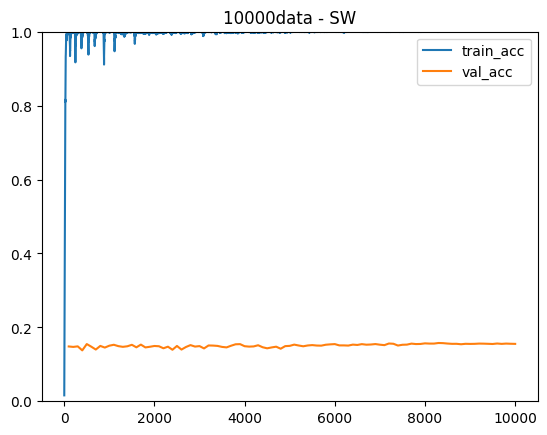

In [103]:
run_csv = pl.read_csv("/home/tat/research/ee/20250507_mn_compare/exp_opt/runs/137/_metrics.csv")

x_col = "epoch"
y_cols = ["train_acc", "val_acc"]

fig, ax = plt.subplots()
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), squeeze=False)
for y_col in y_cols:
    x = run_csv[x_col].to_list()
    y = run_csv[y_col].to_list()
    # Noneの値を除外
    x, y = zip(*[(xi, yi) for xi, yi in zip(x, y) if yi is not None])
    ax.plot(x, y, label=y_col)
ax.legend()
ax.set_ylim([0, 1])
ax.set_title(f"10000data - SW", fontsize=12)
plt.show()
